# 03a — CNN from Scratch · Alertreck Threat Detection

**Model:** 4-block CNN trained on 128-bin log-mel spectrograms  
**Classes:** 7 fine-grained (background_animals, background_wind_rain, threat_chainsaw, threat_dog, threat_gunshot, threat_human, threat_vehicle)  
**Data:** `data/processed/mel/` shards from Stage 2 preprocessing  
**Platform:** Local (alertreck conda env) — or Kaggle with GPU

---

## Local Setup

Run from the repo root with the alertreck conda env:
```bash
conda activate alertreck
conda install -n alertreck -c conda-forge pytorch torchvision seaborn -y
jupyter notebook notebooks/03a-train-cnn.ipynb
```

In [1]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import os
# Reduce CUDA fragmentation OOM on the 15 GB Kaggle T4. MUST be set before torch
# initialises CUDA — if you change it, restart the kernel for it to take effect.
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import gc
import json
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm
import seaborn as sns

print(f'PyTorch  {torch.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device   {device}')
if device.type == 'cuda':
    print(f'GPU      {torch.cuda.get_device_name(0)}')
    print(f'VRAM     {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch  2.10.0+cu128
Device   cuda
GPU      Tesla T4
VRAM     15.6 GB


In [2]:
# ── 2. Config ─────────────────────────────────────────────────────────────────
CFG = {
    # paths — relative to notebooks/ directory
    'data_root':   Path('/kaggle/input/datasets/orpheusmanga/alertreck-mels/mel'),
    'output_dir':  Path('/kaggle/working/models/custom_cnn'),

    # model
    'n_classes':   7,
    'in_channels': 1,

    # spectrogram shape from Stage 2 (SR=44100, clip=3s, hop_stft=441, center=True)
    # actual shard shape verified: (128, 301)
    'n_mels':      128,
    'n_frames':    301,

    # training
    'seed':        42,
    'epochs':      60,
    'batch_size':  256,
    'lr':          1e-3,
    'weight_decay':1e-4,
    'patience':    10,       # early stopping on val macro-F1

    # focal loss
    'focal_gamma': 2.0,

    # curriculum phase epoch budgets (A → B → C)
    # Phase A: clean + SNR≥15dB augmented clips
    # Phase B: clean + 10–15dB augmented clips
    # Phase C: clean + 5–10dB augmented clips (hardest)
    'phase_epochs': {'A': 20, 'B': 15, 'C': 999},

    # labels (must match label_map in manifest.json)
    'label_names': [
        'background_animals',
        'background_wind_rain',
        'threat_chainsaw',
        'threat_dog',
        'threat_gunshot',
        'threat_human',
        'threat_vehicle',
    ],
}

CFG['output_dir'].mkdir(parents=True, exist_ok=True)

random.seed(CFG['seed'])
np.random.seed(CFG['seed'])
torch.manual_seed(CFG['seed'])
if device.type == 'cuda':
    torch.cuda.manual_seed_all(CFG['seed'])

print('Config OK')
print(f"Data root : {CFG['data_root'].resolve()}")
print(f"Output    : {CFG['output_dir'].resolve()}")
print(f"Mel shape : ({CFG['n_mels']}, {CFG['n_frames']})")


Config OK
Data root : /kaggle/input/datasets/orpheusmanga/alertreck-mels/mel
Output    : /kaggle/working/models/custom_cnn
Mel shape : (128, 301)


In [3]:
# ── 3. Dataset ────────────────────────────────────────────────────────────────
class ShardDataset(Dataset):
    """
    Loads all .npz shards from a split directory into memory.
    Each shard contains X (N, 128, 301) float32 and y (N,) int8.
    """
    def __init__(self, shard_dir: Path, augment: bool = False):
        shards = sorted(shard_dir.glob('*.npz'))
        assert shards, f'No shards found in {shard_dir}'

        xs, ys = [], []
        for s in tqdm(shards, desc=f'Loading {shard_dir.name}'):
            d = np.load(s)
            xs.append(d['X'])
            ys.append(d['y'].astype(np.int64))

        self.X = np.concatenate(xs, axis=0)   # (N, 128, 300)
        self.y = np.concatenate(ys, axis=0)   # (N,)
        self.augment = augment
        print(f'  {shard_dir.name}: {len(self.X):,} samples')

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].copy()
        mean_val = x.mean()

        if self.augment:
            # SpecAugment — 2 freq masks (max 20 bins) + 2 time masks (max 40 frames)
            for _ in range(2):
                f_width = random.randint(0, 20)
                f0 = random.randint(0, x.shape[0] - f_width)
                x[f0:f0 + f_width, :] = mean_val
            for _ in range(2):
                t_width = random.randint(0, 40)
                t0 = random.randint(0, x.shape[1] - t_width)
                x[:, t0:t0 + t_width] = mean_val

        # add channel dim → (1, 128, 301)
        x = torch.from_numpy(x).unsqueeze(0)
        y = torch.tensor(self.y[idx], dtype=torch.long)
        return x, y


data_root = CFG['data_root']


# ── load all splits ───────────────────────────────────────────────────────────
print('\nLoading clean splits …')
train_clean_ds = ShardDataset(data_root / 'train',       augment=True)
val_ds         = ShardDataset(data_root / 'val',         augment=False)
test_ds        = ShardDataset(data_root / 'test',        augment=False)

print('\nLoading curriculum augmentation phases …')
train_aug_A_ds = ShardDataset(data_root / 'train_aug_A', augment=True)
train_aug_B_ds = ShardDataset(data_root / 'train_aug_B', augment=True)
train_aug_C_ds = ShardDataset(data_root / 'train_aug_C', augment=True)

# ── curriculum: each phase concatenates clean + augmented shards ─────────────
from torch.utils.data import ConcatDataset

phase_datasets = {
    'A': ConcatDataset([train_clean_ds, train_aug_A_ds]),
    'B': ConcatDataset([train_clean_ds, train_aug_B_ds]),
    'C': ConcatDataset([train_clean_ds, train_aug_C_ds]),
}

def make_train_loader(phase: str) -> DataLoader:
    return DataLoader(phase_datasets[phase], batch_size=CFG['batch_size'],
                      shuffle=True, num_workers=4, pin_memory=True)

val_loader  = DataLoader(val_ds,  batch_size=CFG['batch_size'],
                         shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=CFG['batch_size'],
                         shuffle=False, num_workers=4, pin_memory=True)

print(f'\nVal batches: {len(val_loader)}')
print(f'Phase A train size: {len(phase_datasets["A"]):,}')
print(f'Phase B train size: {len(phase_datasets["B"]):,}')
print(f'Phase C train size: {len(phase_datasets["C"]):,}')


Loading clean splits …


Loading train:   0%|          | 0/16 [00:00<?, ?it/s]

  train: 15,890 samples


Loading val:   0%|          | 0/6 [00:00<?, ?it/s]

  val: 5,383 samples


...

  train_aug_A: 15,890 samples


Loading train_aug_B:   0%|          | 0/32 [00:00<?, ?it/s]

  train_aug_B: 31,780 samples


Loading train_aug_C:   0%|          | 0/48 [00:00<?, ?it/s]

  train_aug_C: 47,670 samples

Val batches: 22
Phase A train size: 31,780
Phase B train size: 47,670
Phase C train size: 63,560


In [4]:
# ── 4. Class weights (handle imbalance) ───────────────────────────────────────
# Use train_clean_ds for class weight computation (clean labels only)
counts = np.bincount(train_clean_ds.y, minlength=CFG['n_classes']).astype(np.float32)
weights = counts.sum() / (CFG['n_classes'] * counts)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print('Class weights:')
for i, (name, w) in enumerate(zip(CFG['label_names'], weights)):
    print(f'  [{i}] {name:<26}  n={int(counts[i]):>6}  weight={w:.3f}')

Class weights:
  [0] background_animals          n=  3354  weight=0.677
  [1] background_wind_rain        n=  4741  weight=0.479
  [2] threat_chainsaw             n=  1540  weight=1.474
  [3] threat_dog                  n=   740  weight=3.068
  [4] threat_gunshot              n=  2582  weight=0.879
  [5] threat_human                n=  2280  weight=0.996
  [6] threat_vehicle              n=   653  weight=3.476


In [5]:
# ── 5. CNN Architecture ───────────────────────────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        return self.block(x)


class AudioCNN(nn.Module):
    """
    4-block CNN for mel spectrogram classification.
    Input:  (B, 1, 128, 301)
    Output: (B, n_classes)

    AdaptiveAvgPool2d((1,1)) makes the classifier input-shape agnostic.
    Encoder output → (B, 256, H, W) → pool → (B, 256).

    `conv_dropout` and `fc_dropout` are exposed so the hyperparameter search
    (cell 6b) can tune regularisation; defaults reproduce the original model.
    """
    def __init__(self, n_classes: int, conv_dropout: float = 0.2, fc_dropout: float = 0.5):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(1,   32,  dropout=conv_dropout),
            ConvBlock(32,  64,  dropout=conv_dropout),
            ConvBlock(64,  128, dropout=conv_dropout),
            ConvBlock(128, 256, dropout=conv_dropout),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(fc_dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.pool(x)
        return self.classifier(x)

    def encode(self, x):
        """Return 256-dim embedding (used by ProtoNet Stage 3c)."""
        return self.pool(self.encoder(x)).flatten(1)


model = AudioCNN(n_classes=CFG['n_classes']).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters: {n_params:,}')

# sanity-check with correct shape (128, 301)
dummy = torch.randn(2, 1, CFG['n_mels'], CFG['n_frames']).to(device)
out   = model(dummy)
emb   = model.encode(dummy)
print(f'Forward pass OK : input {tuple(dummy.shape)} → logits {tuple(out.shape)}')
print(f'Encoder embed   : {tuple(emb.shape)}')

Parameters: 1,206,439
Forward pass OK : input (2, 1, 128, 301) → logits (2, 7)
Encoder embed   : (2, 256)


In [6]:
# ── 6. Loss, optimiser, scheduler ─────────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Focal loss with per-class alpha weighting.
    gamma=2 down-weights well-classified examples so the model
    focuses on the rare / hard classes (threat_dog, threat_vehicle).
    """
    def __init__(self, alpha: torch.Tensor, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha          # (n_classes,) class weights
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce = nn.functional.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce)
        alpha_t = self.alpha[targets]
        loss = alpha_t * (1 - pt) ** self.gamma * ce
        return loss.mean()


criterion = FocalLoss(alpha=class_weights, gamma=CFG['focal_gamma'])

optimizer = optim.AdamW(model.parameters(),
                        lr=CFG['lr'], weight_decay=CFG['weight_decay'])

# CosineAnnealingLR decays smoothly over all epochs — better than
# ReduceLROnPlateau which can stall a curriculum phase mid-run
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['epochs'], eta_min=1e-6,
)


## 6b · Three hyperparameter experiments (replaces Optuna)

The Optuna short-proxy search (6 epochs) selected a fast-converging but **worse-generalising** config — `lr=1.9e-3, bs=128, fc_dropout=0.59` — which trained to only **0.868** test macro-F1 vs **0.918** for the defaults. The proxy was biased toward high learning rates (low-LR configs hadn't converged in 6 epochs, so they were pruned).

So instead we run **three explicit experiments**, each trained through the **full curriculum** around the known-good baseline, and keep the model with the highest **val macro-F1**:

| | lr | batch | weight_decay | focal_γ | conv_drop | fc_drop |
|---|---|---|---|---|---|---|
| **A** baseline | 1e-3 | 256 | 1e-4 | 2.0 | 0.2 | 0.5 |
| **B** gentler | 5e-4 | 256 | 1e-4 | 2.0 | 0.2 | 0.4 |
| **C** more reg | 1e-3 | 256 | 3e-4 | 2.5 | 0.3 | 0.5 |

The winner's checkpoint becomes `best_model.pt`, the comparison is saved to `experiments.json`, and the downstream eval/ONNX cells run on it unchanged.

> **Cost:** three full curricula ≈ 3–4 h on a T4. Lower `CFG['epochs']` or drop an experiment if your session is tight.

In [ ]:
# ── 6b. Three hyperparameter experiments ──────────────────────────────────────
# Each config is trained through the FULL curriculum (cell 8b) with the fixed
# early-stop, and the best by VALIDATION macro-F1 is kept (logged to
# experiments.json). Configs span learning rate and regularisation around a
# known-good baseline; batch_size stays 256. Selection is on val only — the test
# set is untouched until the final evaluation.
EXPERIMENTS = [
    {'name': 'A_baseline', 'lr': 1e-3, 'batch_size': 256, 'weight_decay': 1e-4,
     'focal_gamma': 2.0, 'conv_dropout': 0.2, 'fc_dropout': 0.5},
    {'name': 'B_gentler',  'lr': 5e-4, 'batch_size': 256, 'weight_decay': 1e-4,
     'focal_gamma': 2.0, 'conv_dropout': 0.2, 'fc_dropout': 0.4},
    {'name': 'C_morereg',  'lr': 1e-3, 'batch_size': 256, 'weight_decay': 3e-4,
     'focal_gamma': 2.5, 'conv_dropout': 0.3, 'fc_dropout': 0.5},
]

print(f'{len(EXPERIMENTS)} experiments — each runs the full curriculum (~3–4 h total on T4):')
for e in EXPERIMENTS:
    print(f"  {e['name']:<12} " + "  ".join(f'{k}={v}' for k, v in e.items() if k != 'name'))

In [8]:
# ── 7. Training utilities ─────────────────────────────────────────────────────
def run_epoch(loader, training: bool):
    model.train() if training else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    all_preds, all_labels = [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss   = criterion(logits, y)

            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            preds = logits.argmax(1)
            total_loss += loss.item() * len(y)
            correct    += (preds == y).sum().item()
            n          += len(y)
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())

    epoch_f1 = f1_score(
        torch.cat(all_labels).numpy(),
        torch.cat(all_preds).numpy(),
        average='macro', zero_division=0,
    )
    return total_loss / n, correct / n, epoch_f1


def predict_all(loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in loader:
            preds = model(X.to(device)).argmax(1).cpu()
            all_preds.append(preds)
            all_labels.append(y)
    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()


In [ ]:
# ── 8. Train the 3 experiments (full curriculum) & keep the best ──────────────
import shutil

best_model_path = CFG['output_dir'] / 'best_model.pt'


def get_phase(epoch: int) -> str:
    if epoch <= CFG['phase_epochs']['A']:
        return 'A'
    elif epoch <= CFG['phase_epochs']['A'] + CFG['phase_epochs']['B']:
        return 'B'
    return 'C'


def run_experiment(exp: dict):
    """Full-curriculum training for one config. Rebuilds the module globals
    (model/criterion/optimizer/scheduler) so run_epoch() uses them, saves a
    per-experiment checkpoint, and returns (best_val_f1, best_epoch, history, ckpt)."""
    global model, criterion, optimizer, scheduler
    CFG['batch_size'] = exp['batch_size']        # make_train_loader reads this

    model     = AudioCNN(CFG['n_classes'], conv_dropout=exp['conv_dropout'],
                         fc_dropout=exp['fc_dropout']).to(device)
    criterion = FocalLoss(alpha=class_weights, gamma=exp['focal_gamma'])
    optimizer = optim.AdamW(model.parameters(), lr=exp['lr'],
                            weight_decay=exp['weight_decay'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['epochs'], eta_min=1e-6)

    hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
            'train_f1': [], 'val_f1': [], 'phase': [], 'lr': []}
    best_f1, best_ep, patience = 0.0, 0, 0
    ckpt_path = CFG['output_dir'] / f"model_{exp['name']}.pt"
    cur_phase, train_loader = None, None

    print(f"\n=== {exp['name']} === lr={exp['lr']:.0e} bs={exp['batch_size']} "
          f"wd={exp['weight_decay']:.0e} gamma={exp['focal_gamma']} "
          f"cdrop={exp['conv_dropout']} fdrop={exp['fc_dropout']}", flush=True)
    t0 = time.time()
    for epoch in range(1, CFG['epochs'] + 1):
        phase = get_phase(epoch)
        if phase != cur_phase:
            cur_phase = phase
            train_loader = make_train_loader(phase)
            patience = 0          # give each curriculum phase its own early-stop budget
            if device.type == 'cuda':
                torch.cuda.empty_cache()

        tr_loss, tr_acc, tr_f1 = run_epoch(train_loader, training=True)
        va_loss, va_acc, va_f1 = run_epoch(val_loader,   training=False)
        scheduler.step()

        for k, v in [('train_loss', tr_loss), ('val_loss', va_loss),
                     ('train_acc', tr_acc), ('val_acc', va_acc),
                     ('train_f1', tr_f1), ('val_f1', va_f1),
                     ('phase', phase), ('lr', optimizer.param_groups[0]['lr'])]:
            hist[k].append(v)

        flag = ''
        if va_f1 > best_f1:
            best_f1, best_ep, patience = va_f1, epoch, 0
            torch.save({'epoch': epoch, 'phase': phase, 'model_state': model.state_dict(),
                        'optim_state': optimizer.state_dict(),
                        'val_loss': va_loss, 'val_acc': va_acc, 'val_f1': va_f1,
                        'exp': exp, 'cfg': {k: str(v) for k, v in CFG.items()}}, ckpt_path)
            flag = ' ✓'
        else:
            patience += 1
        print(f"  [{phase}] ep {epoch:02d}  va_F1={va_f1:.4f} (best {best_f1:.4f}){flag}", flush=True)
        # only early-stop in the final phase so the full A->B->C curriculum always runs
        if phase == 'C' and patience >= CFG['patience']:
            print(f"  early stop at epoch {epoch}", flush=True)
            break

    print(f"  → {exp['name']} best val macro-F1 = {best_f1:.4f} "
          f"(epoch {best_ep}, {(time.time()-t0)/60:.1f} min)", flush=True)
    return best_f1, best_ep, hist, ckpt_path


exp_results = []
for exp in EXPERIMENTS:
    bf1, bep, hist, ckpt = run_experiment(exp)
    exp_results.append({'name': exp['name'], 'val_f1': bf1, 'epoch': bep,
                        'ckpt': str(ckpt), 'history': hist, 'exp': exp})
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()

# ── pick the winner and adopt it ──────────────────────────────────────────────
best = max(exp_results, key=lambda r: r['val_f1'])
shutil.copy(best['ckpt'], best_model_path)

print("\n" + "=" * 56)
print("Experiment comparison (val macro-F1):")
for r in sorted(exp_results, key=lambda r: -r['val_f1']):
    mark = '   <-- BEST' if r['name'] == best['name'] else ''
    print(f"  {r['name']:<12} {r['val_f1']:.4f}  (epoch {r['epoch']}){mark}")
print(f"\nBest model → {best_model_path}  ({best['name']}, val_F1={best['val_f1']:.4f})")
print("=" * 56)

# adopt the best config + rebuild the global model with its weights for downstream
CFG.update(best['exp'])
history = best['history']
model = AudioCNN(CFG['n_classes'], conv_dropout=best['exp']['conv_dropout'],
                 fc_dropout=best['exp']['fc_dropout']).to(device)
model.load_state_dict(torch.load(best_model_path, map_location=device)['model_state'])

# persist the experiment comparison
(CFG['output_dir'] / 'experiments.json').write_text(json.dumps(
    [{'name': r['name'], 'val_f1': r['val_f1'], 'epoch': r['epoch'], 'config': r['exp']}
     for r in exp_results], indent=2))
print(f"Comparison saved → {CFG['output_dir'] / 'experiments.json'}")

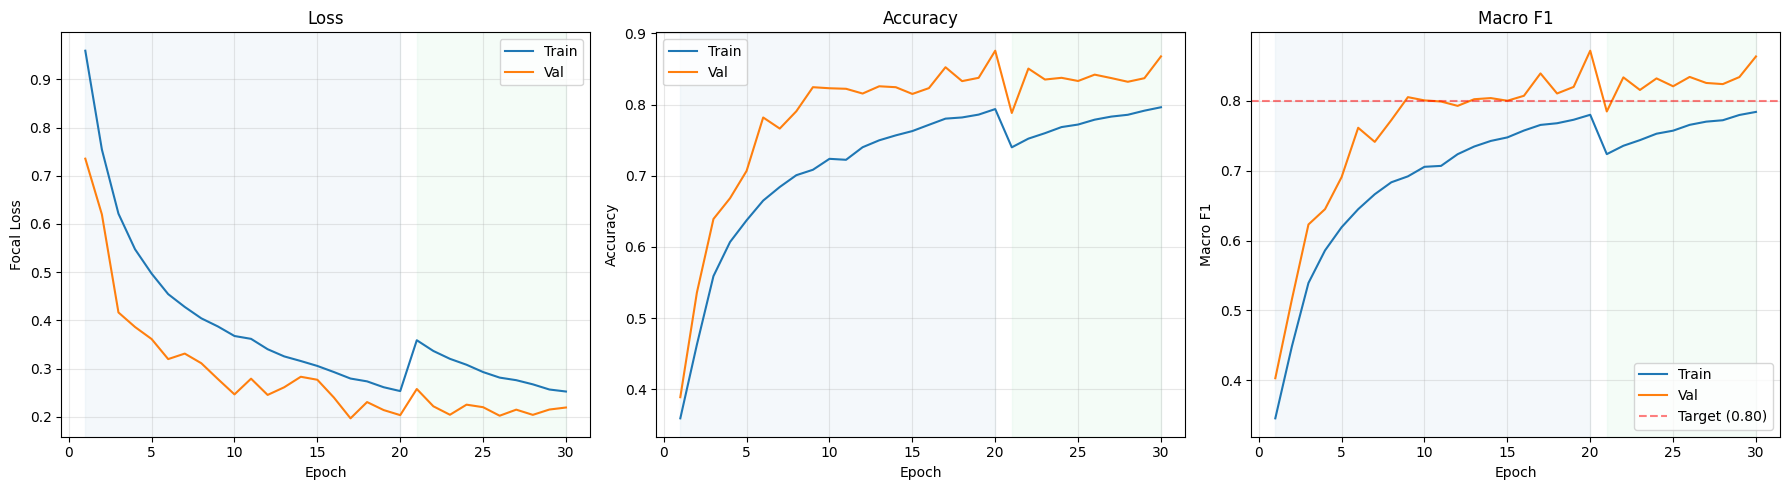

In [10]:
# ── 9. Training curves ────────────────────────────────────────────────────────
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_ran, history['train_loss'], label='Train')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Focal Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history['train_acc'], label='Train')
axes[1].plot(epochs_ran, history['val_acc'],   label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_ran, history['train_f1'], label='Train')
axes[2].plot(epochs_ran, history['val_f1'],   label='Val')
axes[2].axhline(0.80, color='red', linestyle='--', alpha=0.5, label='Target (0.80)')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Macro F1')
axes[2].set_title('Macro F1'); axes[2].legend(); axes[2].grid(alpha=0.3)

# shade curriculum phases
phase_list = history['phase']
for ax in axes:
    for i, (p, color) in enumerate([('A','#d4e6f1'), ('B','#d5f5e3'), ('C','#fdebd0')]):
        start = next((e+1 for e, ph in enumerate(phase_list) if ph == p), None)
        end   = max((e+1 for e, ph in enumerate(phase_list) if ph == p), default=None)
        if start and end:
            ax.axvspan(start, end, alpha=0.25, color=color, label=f'Phase {p}')

plt.tight_layout()
plt.savefig(CFG['output_dir'] / 'training_curves.png', dpi=150)
plt.show()


In [11]:
# ── 10. Load best model & evaluate on test set ────────────────────────────────
from sklearn.metrics import (
    balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score,
)

checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state'])
print(f"Loaded best model from epoch {checkpoint['epoch']} "
      f"(val_F1={checkpoint['val_f1']:.4f}, val_loss={checkpoint['val_loss']:.4f})")

test_preds, test_labels = predict_all(test_loader)

# ── headline metrics ─────────────────────────────────────────────────────────
# macro-F1 is the primary metric (every class weighted equally — the right choice
# for imbalanced threat detection). micro = global, weighted = support-weighted.
test_acc     = (test_preds == test_labels).mean()
macro_f1     = f1_score(test_labels, test_preds, average='macro',    zero_division=0)
micro_f1     = f1_score(test_labels, test_preds, average='micro',    zero_division=0)
weighted_f1  = f1_score(test_labels, test_preds, average='weighted', zero_division=0)
balanced_acc = balanced_accuracy_score(test_labels, test_preds)
mcc          = matthews_corrcoef(test_labels, test_preds)
kappa        = cohen_kappa_score(test_labels, test_preds)
test_f1      = macro_f1   # primary metric; downstream cells reference test_f1

print('\n=== Test-set metrics ===')
print(f'  Accuracy           : {test_acc:.4f}')
print(f'  Balanced accuracy  : {balanced_acc:.4f}')
print(f'  Macro-F1  (primary): {macro_f1:.4f}')
print(f'  Micro-F1           : {micro_f1:.4f}')
print(f'  Weighted-F1        : {weighted_f1:.4f}')
print(f"  Matthews corr (MCC): {mcc:.4f}")
print(f"  Cohen's kappa      : {kappa:.4f}")

Loaded best model from epoch 20 (val_F1=0.8716, val_loss=0.2034)

=== Test-set metrics ===
  Accuracy           : 0.8710
  Balanced accuracy  : 0.8716
  Macro-F1  (primary): 0.8677
  Micro-F1           : 0.8710
  Weighted-F1        : 0.8718
  Matthews corr (MCC): 0.8403
  Cohen's kappa      : 0.8401


In [12]:
# ── 11. Per-class classification report ───────────────────────────────────────
print(classification_report(test_labels, test_preds,
                             target_names=CFG['label_names'], digits=4))

                      precision    recall  f1-score   support

  background_animals     0.8858    0.8888    0.8873      1187
background_wind_rain     0.8572    0.8561    0.8567      1578
     threat_chainsaw     0.7549    0.8953    0.8191       516
          threat_dog     0.7915    0.8402    0.8151       244
      threat_gunshot     0.9205    0.8707    0.8949       851
        threat_human     0.9373    0.8635    0.8989       762
      threat_vehicle     0.9171    0.8868    0.9017       212

            accuracy                         0.8710      5350
           macro avg     0.8663    0.8716    0.8677      5350
        weighted avg     0.8745    0.8710    0.8718      5350



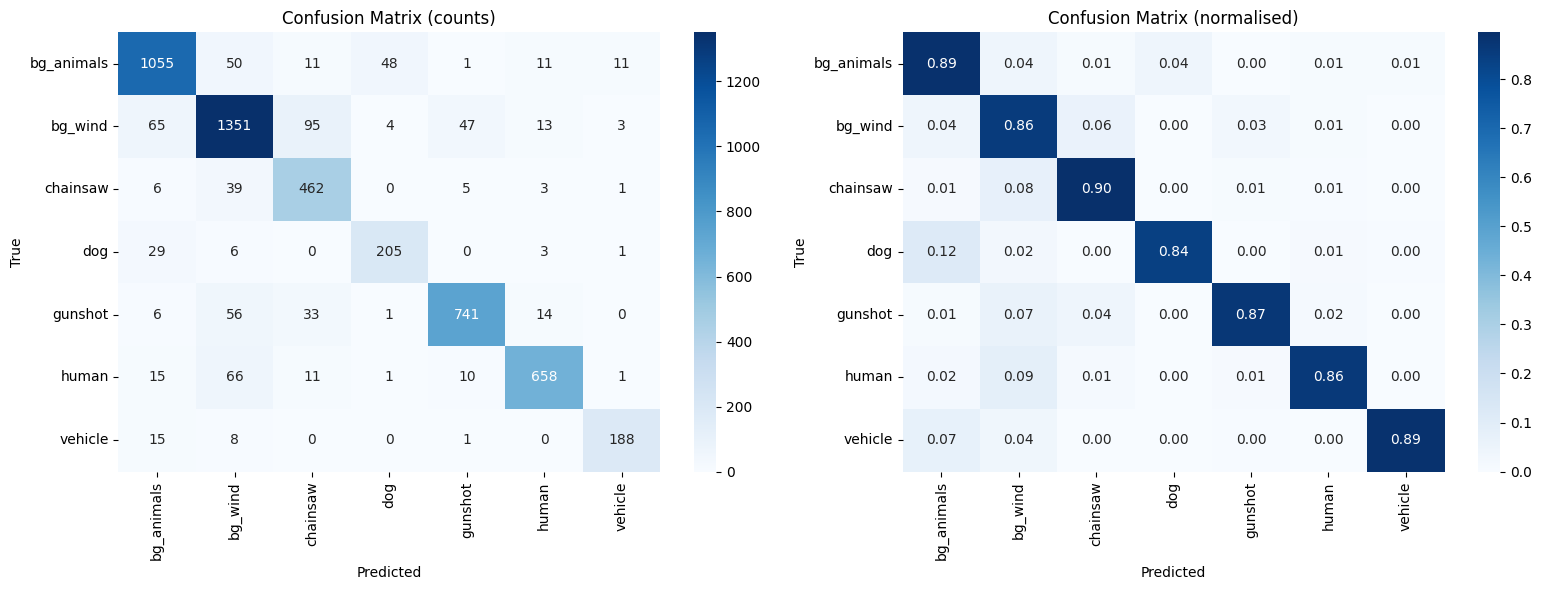

In [13]:
# ── 12. Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

short_names = ['bg_animals', 'bg_wind', 'chainsaw', 'dog', 'gunshot', 'human', 'vehicle']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Confusion Matrix (counts)', 'Confusion Matrix (normalised)'],
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=short_names, yticklabels=short_names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title)

plt.tight_layout()
plt.savefig(CFG['output_dir'] / 'confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
# ── 13. Save results JSON ─────────────────────────────────────────────────────
results = {
    'model':        'CNN from scratch',
    'best_epoch':   int(checkpoint['epoch']),
    'val_loss':     float(checkpoint['val_loss']),
    'val_acc':      float(checkpoint['val_acc']),
    'test_acc':         float(test_acc),
    'test_balanced_acc': float(balanced_acc),
    'test_macro_f1':    float(macro_f1),
    'test_micro_f1':    float(micro_f1),
    'test_weighted_f1': float(weighted_f1),
    'test_mcc':         float(mcc),
    'test_cohen_kappa': float(kappa),
    'per_class_f1': {
        name: float(f1_score(test_labels == i, test_preds == i, average='binary'))
        for i, name in enumerate(CFG['label_names'])
    },
    'best_config': checkpoint.get('exp'),
    'experiments': json.loads((CFG['output_dir'] / 'experiments.json').read_text())
                   if (CFG['output_dir'] / 'experiments.json').exists() else None,
    'n_params':     n_params,
    'history':      history,
}

results_path = CFG['output_dir'] / 'results.json'
results_path.write_text(json.dumps(results, indent=2))
print(f'Results saved → {results_path}')

print('\n=== Summary ===')
print(f"Test accuracy : {test_acc:.4f}")
print(f"Test macro-F1 : {macro_f1:.4f}  (micro {micro_f1:.4f} · weighted {weighted_f1:.4f})")
print(f"MCC / kappa   : {mcc:.4f} / {kappa:.4f}")
print(f"Best config   : {checkpoint.get('exp', {}).get('name', 'n/a')}")
print(f"Parameters    : {n_params:,}")
print(f"Best epoch    : {checkpoint['epoch']}")

=== AUC-ROC (target > 0.85) ===
  background_animals          AUC=0.9864  ✓
  background_wind_rain        AUC=0.9769  ✓
  threat_chainsaw             AUC=0.9816  ✓
  threat_dog                  AUC=0.9874  ✓
  threat_gunshot              AUC=0.9830  ✓
  threat_human                AUC=0.9828  ✓
  threat_vehicle              AUC=0.9897  ✓
  macro average               AUC=0.9840

=== Precision / Recall / F1 per class ===
  Class                         Prec     Rec      F1      AP
  --------------------------------------------------------
  background_animals          0.8858  0.8888  0.8873  0.9582
  background_wind_rain        0.8572  0.8561  0.8567  0.9480
  threat_chainsaw             0.7549  0.8953  0.8191  0.9143
  threat_dog                  0.7915  0.8402  0.8151  0.9033
  threat_gunshot              0.9205  0.8707  0.8949  0.9511
  threat_human                0.9373  0.8635  0.8989  0.9484
  threat_vehicle              0.9171  0.8868  0.9017  0.9508
  macro average              

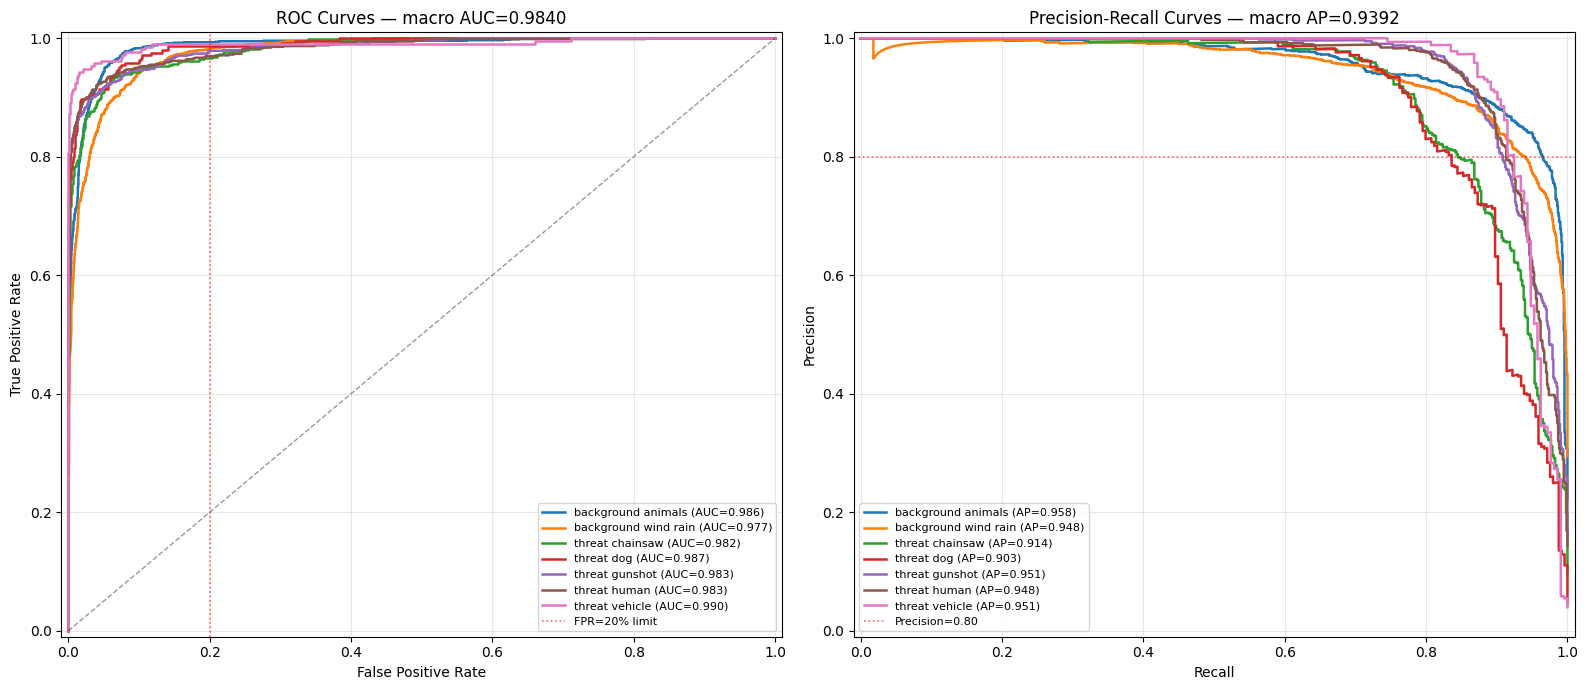


=== False Positive Rate @ argmax threshold ===
  background_animals          FPR=0.0327  ✓
  background_wind_rain        FPR=0.0597  ✓
  threat_chainsaw             FPR=0.0310  ✓
  threat_dog                  FPR=0.0106  ✓
  threat_gunshot              FPR=0.0142  ✓
  threat_human                FPR=0.0096  ✓
  threat_vehicle              FPR=0.0033  ✓

AUC/AP metrics appended → /kaggle/working/models/custom_cnn/results.json


In [15]:
# ── 14. AUC-ROC + Precision-Recall evaluation ────────────────────────────────
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    precision_score, recall_score,
)
from sklearn.preprocessing import label_binarize
import torch.nn.functional as F

# ── collect softmax probabilities on the test set ────────────────────────────
model.eval()
all_probs, all_labels_list = [], []
with torch.no_grad():
    for X, y in test_loader:
        logits = model(X.to(device))
        probs  = F.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels_list.append(y.numpy())

probs_all  = np.concatenate(all_probs,       axis=0)   # (N, 7)
labels_all = np.concatenate(all_labels_list, axis=0)   # (N,)

# one-hot encode labels for sklearn multi-class ROC
labels_bin = label_binarize(labels_all, classes=list(range(CFG['n_classes'])))

# ── per-class AUC-ROC ─────────────────────────────────────────────────────────
auc_scores = {}
for i, name in enumerate(CFG['label_names']):
    auc_scores[name] = roc_auc_score(labels_bin[:, i], probs_all[:, i])

macro_auc = roc_auc_score(labels_bin, probs_all, average='macro')

print("=== AUC-ROC (target > 0.85) ===")
for name, auc in auc_scores.items():
    flag = '✓' if auc >= 0.85 else '✗ BELOW TARGET'
    print(f"  {name:<26}  AUC={auc:.4f}  {flag}")
print(f"  {'macro average':<26}  AUC={macro_auc:.4f}")

# ── per-class precision / recall ─────────────────────────────────────────────
preds_all = probs_all.argmax(axis=1)
print("\n=== Precision / Recall / F1 per class ===")
print(f"  {'Class':<26}  {'Prec':>6}  {'Rec':>6}  {'F1':>6}  {'AP':>6}")
print("  " + "-" * 56)
ap_scores = {}
for i, name in enumerate(CFG['label_names']):
    prec  = precision_score(labels_all == i, preds_all == i, zero_division=0)
    rec   = recall_score(labels_all == i, preds_all == i, zero_division=0)
    f1_i  = 2 * prec * rec / (prec + rec + 1e-9)
    ap    = average_precision_score(labels_bin[:, i], probs_all[:, i])
    ap_scores[name] = ap
    print(f"  {name:<26}  {prec:>6.4f}  {rec:>6.4f}  {f1_i:>6.4f}  {ap:>6.4f}")

macro_ap = np.mean(list(ap_scores.values()))
print(f"  {'macro average':<26}  {'':>6}  {'':>6}  {test_f1:>6.4f}  {macro_ap:>6.4f}")

# ── ROC curves ────────────────────────────────────────────────────────────────
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
for i, (name, color) in enumerate(zip(CFG['label_names'], colors)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], probs_all[:, i])
    ax.plot(fpr, tpr, color=color, lw=1.8,
            label=f'{name.replace("_"," ")} (AUC={auc_scores[name]:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
ax.axvline(0.20, color='red', linestyle=':', lw=1.2, alpha=0.6, label='FPR=20% limit')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC Curves — macro AUC={macro_auc:.4f}')
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

# ── Precision-Recall curves ───────────────────────────────────────────────────
ax = axes[1]
for i, (name, color) in enumerate(zip(CFG['label_names'], colors)):
    prec_c, rec_c, _ = precision_recall_curve(labels_bin[:, i], probs_all[:, i])
    ax.plot(rec_c, prec_c, color=color, lw=1.8,
            label=f'{name.replace("_"," ")} (AP={ap_scores[name]:.3f})')
ax.axhline(0.80, color='red', linestyle=':', lw=1.2, alpha=0.6, label='Precision=0.80')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall Curves — macro AP={macro_ap:.4f}')
ax.legend(fontsize=8, loc='lower left')
ax.grid(alpha=0.3)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
plt.savefig(CFG['output_dir'] / 'roc_pr_curves.png', dpi=150)
plt.show()

# ── FPR @ operating threshold (argmax) ───────────────────────────────────────
print("\n=== False Positive Rate @ argmax threshold ===")
for i, name in enumerate(CFG['label_names']):
    fp = ((preds_all == i) & (labels_all != i)).sum()
    tn = ((preds_all != i) & (labels_all != i)).sum()
    fpr_op = fp / (fp + tn) if (fp + tn) > 0 else 0
    flag = '✓' if fpr_op < 0.20 else '✗ ABOVE LIMIT'
    print(f"  {name:<26}  FPR={fpr_op:.4f}  {flag}")

# ── append AUC / AP to results.json ──────────────────────────────────────────
results_path = CFG['output_dir'] / 'results.json'
results_data = json.loads(results_path.read_text())
results_data['per_class_auc']    = auc_scores
results_data['per_class_ap']     = ap_scores
results_data['macro_auc']        = float(macro_auc)
results_data['macro_ap']         = float(macro_ap)
results_path.write_text(json.dumps(results_data, indent=2))
print(f"\nAUC/AP metrics appended → {results_path}")


In [16]:
# ── 15. Export to ONNX (for Pi deployment via ONNX Runtime) ───────────────────
import torch.onnx

onnx_path = CFG['output_dir'] / 'alertreck_cnn.onnx'

model.eval()
# dummy shape must match actual shard shape: (1, 128, 301)
dummy_input = torch.randn(1, 1, CFG['n_mels'], CFG['n_frames']).to(device)

torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    dynamo=False,                      # legacy TorchScript exporter — no onnxscript dep
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=['mel_spectrogram'],
    output_names=['class_logits'],
    dynamic_axes={
        'mel_spectrogram': {0: 'batch_size'},
        'class_logits':    {0: 'batch_size'},
    },
)
print(f'ONNX model saved → {onnx_path}')
print(f'Input  : (batch, 1, {CFG["n_mels"]}, {CFG["n_frames"]})')
print(f'Output : (batch, {CFG["n_classes"]})')

# save model config alongside for inference script
model_config = {
    'n_classes':   CFG['n_classes'],
    'n_mels':      CFG['n_mels'],
    'n_frames':    CFG['n_frames'],
    'label_names': CFG['label_names'],
    'test_acc':    float(test_acc),
    'test_macro_f1': float(test_f1),
    'best_epoch':  int(checkpoint['epoch']),
    'best_val_f1': float(checkpoint['val_f1']),
    'best_phase':  checkpoint.get('phase', 'unknown'),
}
config_path = CFG['output_dir'] / 'model_config_custom_cnn.json'
config_path.write_text(json.dumps(model_config, indent=2))
print(f'Model config    → {config_path}')


/tmp/ipykernel_58/3800158427.py:10: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


ONNX model saved → /kaggle/working/models/custom_cnn/alertreck_cnn.onnx
Input  : (batch, 1, 128, 301)
Output : (batch, 7)
Model config    → /kaggle/working/models/custom_cnn/model_config_custom_cnn.json
